# Machine Learning үй жұмысы — дайын шешім (.ipynb)

Бұл notebook **Есептер.docx** құжатындағы тапсырмаларды толық орындайды:  
KNN, SVM, Naive Bayes, Decision Tree, Кластерлеу, және Mini-project.

> Ескерту: *20 Newsgroups* датасеті интернет арқылы жүктеледі. Егер ортаңызда интернет болмаса, код автоматты түрде **кішігірім toy мәтін датасетіне** ауысады.



In [1]:
# Орнату және импорттар
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score,
    classification_report
)

import matplotlib.pyplot as plt


In [2]:
# Iris датасеті
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print("X shape:", X.shape)
print("Classes:", class_names)


X shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


## ✅ 1-БӨЛІМ. KNN — тапсырмалар

Талаптар: Iris датасеті, 80/20 split, k=3 және k=7, accuracy салыстыру. fileciteturn1file0L5-L35


In [3]:
from sklearn.neighbors import KNeighborsClassifier

# 80/20 бөлу (deterministic)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def eval_knn(k, Xtr, Xte, ytr, yte):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred)
    return acc, model

acc_k3, knn3 = eval_knn(3, X_train, X_test, y_train, y_test)
acc_k7, knn7 = eval_knn(7, X_train, X_test, y_train, y_test)

print(f"Accuracy (k=3): {acc_k3:.4f}")
print(f"Accuracy (k=7): {acc_k7:.4f}")

best_k = 3 if acc_k3 >= acc_k7 else 7
print("Қорытынды: осы split үшін жақсырақ k =", best_k)


Accuracy (k=3): 1.0000
Accuracy (k=7): 0.9667
Қорытынды: осы split үшін жақсырақ k = 3


**Түсіндірме:**  
- k кішірейген сайын модель “жергілікті” шешім қабылдайды → кейде шумға сезімтал (variance жоғары).  
- k үлкейген сайын шешім “жалпылама” болады → кейде шынайы шекараны “жұмсартады” (bias жоғары).  
Сондықтан k-ны тәжірибелік түрде (валидациямен) таңдаймыз.


### 🔹 Тапсырма 2 (Intermediate): StandardScaler қолдану

KNN — **қашықтыққа** негізделген модель. Сондықтан белгілердің масштабы әртүрлі болса (см, мм сияқты), үлкен масштабтағы feature басым болып кетеді. fileciteturn1file0L39-L47


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Масштабтауға дейін (жоғарыда есептелді)
print("Scaling жоқ (k=7):", acc_k7)

# Масштабтаумен бірге (Pipeline)
pipe_knn7 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])

pipe_knn7.fit(X_train, y_train)
pred_scaled = pipe_knn7.predict(X_test)
acc_scaled = accuracy_score(y_test, pred_scaled)

print(f"StandardScaler + KNN(k=7) accuracy: {acc_scaled:.4f}")

if acc_scaled > acc_k7:
    print("Қорытынды: масштабтау көмектесті.")
elif acc_scaled < acc_k7:
    print("Қорытынды: бұл split үшін масштабтау көмектеспеді (бірақ жалпы KNN үшін пайдалы).")
else:
    print("Қорытынды: айырмашылық жоқ (осы split үшін).")


Scaling жоқ (k=7): 0.9666666666666667
StandardScaler + KNN(k=7) accuracy: 0.9667
Қорытынды: айырмашылық жоқ (осы split үшін).


### 🔹 Тапсырма 3 (Advanced): k = 1..20, k vs accuracy графигі, оптималды k таңдау fileciteturn1file0L52-L63

Best k: 1 Best accuracy: 0.9667


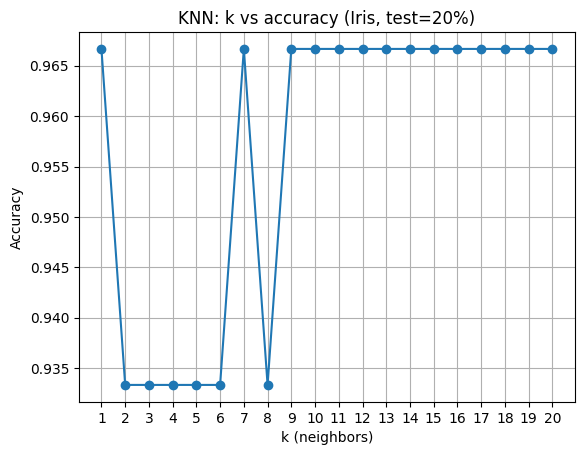

In [5]:
ks = list(range(1, 21))
accs = []

# Әділетті болу үшін scaling қолданамыз (KNN үшін стандарт)
for k in ks:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    accs.append(accuracy_score(y_test, pred))

best_idx = int(np.argmax(accs))
best_k = ks[best_idx]
best_acc = accs[best_idx]

print("Best k:", best_k, "Best accuracy:", round(best_acc, 4))

plt.figure()
plt.plot(ks, accs, marker="o")
plt.xticks(ks)
plt.xlabel("k (neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN: k vs accuracy (Iris, test=20%)")
plt.grid(True)
plt.show()


## ✅ 2-БӨЛІМ. SVM — тапсырмалар fileciteturn1file0L68-L123

SVM-да scaling өте маңызды (әсіресе RBF/Poly kernel үшін). Сондықтан төменде Pipeline қолданамыз.


In [6]:
from sklearn.svm import SVC

kernels = ["linear", "rbf", "poly"]
kernel_results = {}

for ker in kernels:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=ker, random_state=42))
    ])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    kernel_results[ker] = acc

print("Kernel -> accuracy")
for k, v in kernel_results.items():
    print(f"{k:>6} : {v:.4f}")

best_kernel = max(kernel_results, key=kernel_results.get)
print("Қорытынды: осы split үшін ең жақсы kernel =", best_kernel)


Kernel -> accuracy
linear : 1.0000
   rbf : 0.9667
  poly : 0.9000
Қорытынды: осы split үшін ең жақсы kernel = linear


**Неге kernel-дар әртүрлі нәтиже береді?**  
- **linear**: сызықтық бөлінетін/жақын деректерде жылдам және тұрақты.  
- **rbf**: сызықтық емес шекараны жақсы ұстайды; көбіне универсал шешім.  
- **poly**: полиномдық шекара; degree параметріне сезімтал.

Iris жиі жақсы бөлінеді, сондықтан linear немесе rbf жиі жоғары accuracy береді (split-ке байланысты).


### 🔹 Тапсырма 5 (Intermediate): C = 0.1, 1, 10, accuracy және overfitting талдауы fileciteturn1file0L97-L106

- **C кішкентай** → regularization күшті → margin кең → bias ↑ (underfit болуы мүмкін)  
- **C үлкен** → regularization әлсіз → training-ке “жабысады” → variance ↑ (overfit қаупі)


In [7]:
Cs = [0.1, 1, 10]
c_results = []

for C in Cs:
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=C, gamma="scale", random_state=42))
    ])
    clf.fit(X_train, y_train)
    pred_tr = clf.predict(X_train)
    pred_te = clf.predict(X_test)
    acc_tr = accuracy_score(y_train, pred_tr)
    acc_te = accuracy_score(y_test, pred_te)
    c_results.append((C, acc_tr, acc_te))

df_c = pd.DataFrame(c_results, columns=["C", "train_acc", "test_acc"])
df_c


,C,train_acc,test_acc
0,0.1,0.900,0.900000
1,1.0,0.975,0.966667
2,10.0,0.975,0.966667


**Overfitting-ті қалай байқаймыз?**  
Егер **train_acc өте жоғары**, бірақ **test_acc айтарлықтай төмен** болса — overfitting ықтимал.  
Егер екеуі де төмен болса — underfitting ықтимал.


### 🔹 Тапсырма 6 (Advanced): GridSearchCV арқылы C және gamma оптимизация fileciteturn1file0L110-L123

In [8]:
param_grid = {
    "svm__C": [0.1, 1, 10, 30, 100],
    "svm__gamma": ["scale", 0.1, 0.01, 0.001]
}

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", random_state=42))
])

grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", round(grid.best_score_, 4))

best_model = grid.best_estimator_
pred = best_model.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, pred), 4))


Best params: {'svm__C': 1, 'svm__gamma': 0.1}
Best CV score: 0.975
Test accuracy: 0.9667


## ✅ 3-БӨЛІМ. Naive Bayes — тапсырмалар fileciteturn1file1L65-L112

In [9]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
pred = gnb.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="macro")
rec = recall_score(y_test, pred, average="macro")
cm = confusion_matrix(y_test, pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print("\nConfusion Matrix:\n", cm)


Accuracy : 0.9667
Precision: 0.9697
Recall   : 0.9667

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


### 🔹 Тапсырма 8 (Intermediate): 20 Newsgroups + TF-IDF + MultinomialNB, Spam/NotSpam fileciteturn1file1L80-L92

**Ескерту:** 20 Newsgroups — көпсыныпты датасет. Бұл тапсырмаға сай ету үшін біз 2 категорияны таңдап, бірін **Spam**, бірін **Not Spam** деп белгілейміз (binary classification).


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

def load_text_binary_dataset():
    # 20 Newsgroups жүктеу (интернет керек болуы мүмкін)
    try:
        from sklearn.datasets import fetch_20newsgroups
        categories = ["sci.space", "talk.politics.misc"]  # мысал ретінде
        data = fetch_20newsgroups(subset="train", categories=categories, remove=("headers", "footers", "quotes"))
        X_text = data.data
        y_bin = np.array([1 if data.target_names[t] == "talk.politics.misc" else 0 for t in data.target])
        # 1=Spam, 0=NotSpam деп алайық (демонстрация)
        return X_text, y_bin, "20newsgroups"
    except Exception as e:
        # Fallback: toy dataset
        X_text = [
            "Free money now click here",
            "Limited offer buy cheap pills",
            "Meet me at 5 pm to discuss project",
            "The meeting agenda is attached",
            "Win a prize claim your reward",
            "Let us schedule a call for tomorrow",
            "Exclusive deal just for you",
            "Here are the homework instructions",
            "Congratulations you are selected",
            "Please review the document and reply",
        ]
        y_bin = np.array([1,1,0,0,1,0,1,0,1,0])  # 1=spam
        return X_text, y_bin, "toy"

X_text, y_text, source = load_text_binary_dataset()
print("Text source:", source, "| N:", len(X_text))

Xtr, Xte, ytr, yte = train_test_split(X_text, y_text, test_size=0.2, random_state=42, stratify=y_text)

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
Xtr_vec = vectorizer.fit_transform(Xtr)
Xte_vec = vectorizer.transform(Xte)

mnb = MultinomialNB()
mnb.fit(Xtr_vec, ytr)
pred = mnb.predict(Xte_vec)

print("Accuracy:", round(accuracy_score(yte, pred), 4))
print("Confusion Matrix:\n", confusion_matrix(yte, pred))
print("\nReport:\n", classification_report(yte, pred))


Text source: 20newsgroups | N: 1058
Accuracy: 0.9198
Confusion Matrix:
 [[117   2]
 [ 15  78]]

Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93       119
           1       0.97      0.84      0.90        93

    accuracy                           0.92       212
   macro avg       0.93      0.91      0.92       212
weighted avg       0.93      0.92      0.92       212



### 🔹 Тапсырма 9 (Advanced): Naive Bayes vs KNN vs Decision Tree (мәтін үшін) fileciteturn1file1L96-L109

Мәтінде TF-IDF векторлары өте **жоғары өлшемді** және **сирек (sparse)** болады.  
Осы жағдайда жиі жақсы жұмыс істейтін модельдер: **Naive Bayes**, **Linear models**, **SVM**.

Бірақ тапсырма талабына сай: **MultinomialNB**, **KNN**, **Decision Tree** салыстырамыз.


In [11]:
from sklearn.tree import DecisionTreeClassifier

# MultinomialNB (baseline)
mnb = MultinomialNB()
mnb.fit(Xtr_vec, ytr)
pred_nb = mnb.predict(Xte_vec)
acc_nb = accuracy_score(yte, pred_nb)

# KNN: sparse үшін brute + cosine (кейбір sklearn нұсқаларында cosine қолдауы шектеулі болуы мүмкін)
from sklearn.neighbors import KNeighborsClassifier

def fit_knn_text(Xtrv, ytr, Xtev):
    try:
        knn = KNeighborsClassifier(n_neighbors=5, metric="cosine", algorithm="brute")
        knn.fit(Xtrv, ytr)
        return knn.predict(Xtev)
    except Exception:
        # fallback: euclidean (көбіне әлсізірек)
        knn = KNeighborsClassifier(n_neighbors=5, algorithm="brute")
        knn.fit(Xtrv, ytr)
        return knn.predict(Xtev)

pred_knn = fit_knn_text(Xtr_vec, ytr, Xte_vec)
acc_knn = accuracy_score(yte, pred_knn)

# Decision Tree (шамадан тыс overfit болуы мүмкін, сондықтан depth шектеу)
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(Xtr_vec, ytr)
pred_dt = dt.predict(Xte_vec)
acc_dt = accuracy_score(yte, pred_dt)

pd.DataFrame({
    "Model": ["MultinomialNB", "KNN (n=5)", "DecisionTree (depth=10)"],
    "Accuracy": [acc_nb, acc_knn, acc_dt]
})


,Model,Accuracy
0,MultinomialNB,0.919811
1,KNN (n=5),0.882075
2,DecisionTree (depth=10),0.773585


**Қорытынды (типтік):**  
- **Naive Bayes** мәтін үшін көбіне жақсы: сөздер тәуелсіздігі болжамы толық дәл емес, бірақ практикада сирек TF-IDF-те тиімді.  
- **KNN** мәтінде жиі баяу және өлшем көп болғандықтан “distance” мағынасы әлсірейді.  
- **Decision Tree** жоғары өлшемде тез overfit болады (training-ке жабысады).  
Сондықтан мәтін classification үшін Naive Bayes жиі қолайлы таңдау болады.


## ✅ 4-БӨЛІМ. Decision Tree — тапсырмалар fileciteturn1file1L113-L158

In [12]:
from sklearn.tree import DecisionTreeClassifier

depths = [2, 4, 6]
rows = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, tree.predict(X_train))
    te_acc = accuracy_score(y_test, tree.predict(X_test))
    rows.append((d, tr_acc, te_acc))

pd.DataFrame(rows, columns=["max_depth", "train_acc", "test_acc"])


,max_depth,train_acc,test_acc
0,2,0.966667,0.933333
1,4,0.991667,0.933333
2,6,1.000000,0.933333


**Overfitting қай кезде шығады?**  
Depth өскен сайын ағаш күрделенеді → **train_acc өседі**.  
Егер test_acc өсуді тоқтатып төмендей бастаса — overfitting белгісі.


### 🔹 Тапсырма 11 (Intermediate): Ағашты визуализациялау және feature importance fileciteturn1file1L128-L138

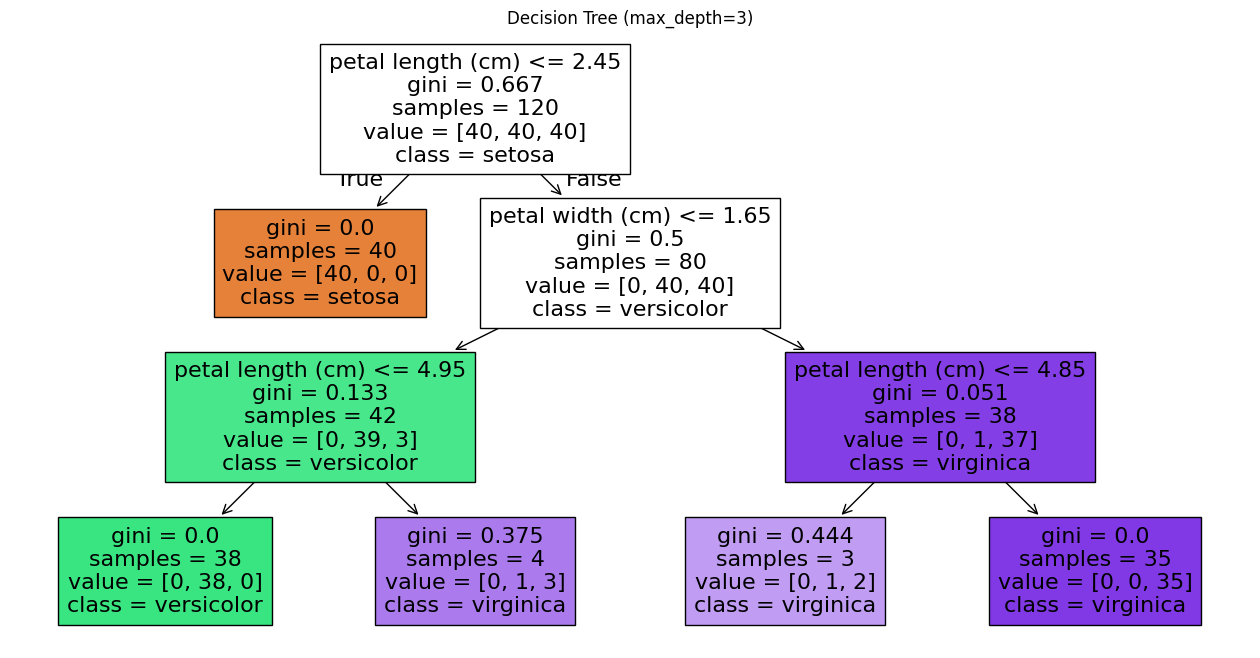

,0
petal length (cm),0.579077
petal width (cm),0.420923
sepal width (cm),0.000000
sepal length (cm),0.000000


In [13]:
from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree (max_depth=3)")
plt.show()

importances = pd.Series(tree.feature_importances_, index=feature_names).sort_values(ascending=False)
importances


### 🔹 Тапсырма 12 (Advanced): Decision Tree vs Random Forest (дәлірек және тұрақты) fileciteturn1file1L142-L154

Random Forest — көптеген ағаштардың ансамблі. Әдетте:  
- **Дәлірек** (variance азаяды)  
- **Тұрақты** (split-ке/шумаға сезімталдығы төмен)


In [14]:
from sklearn.ensemble import RandomForestClassifier

tree = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=300, random_state=42)

tree.fit(X_train, y_train)
rf.fit(X_train, y_train)

pred_tree = tree.predict(X_test)
pred_rf = rf.predict(X_test)

acc_tree = accuracy_score(y_test, pred_tree)
acc_rf = accuracy_score(y_test, pred_rf)

print("Decision Tree accuracy :", round(acc_tree, 4))
print("Random Forest accuracy :", round(acc_rf, 4))


Decision Tree accuracy : 0.9333
Random Forest accuracy : 0.9


## ✅ 5-БӨЛІМ. Кластерлеу — тапсырмалар fileciteturn1file2L75-L112

Кластерлеу — **unsupervised**. Iris-та нақты класс (y) бар болса да, кластерлеуде біз оны оқытуға қолданбаймыз.


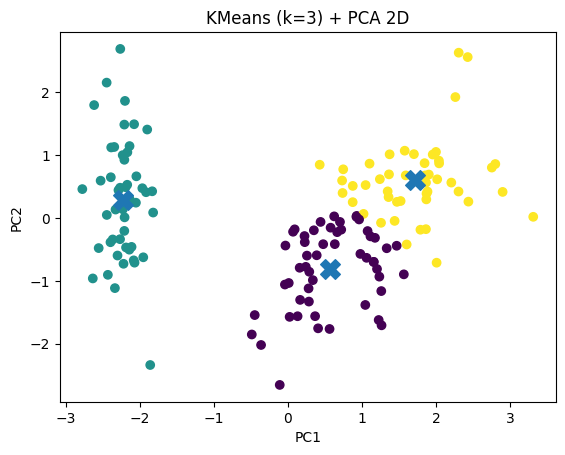

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# KMeans көбіне scaling-тен ұтады
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_scaled)
centers2 = pca.transform(kmeans.cluster_centers_)

plt.figure()
plt.scatter(X2[:, 0], X2[:, 1], c=labels)
plt.scatter(centers2[:, 0], centers2[:, 1], marker="X", s=200)
plt.title("KMeans (k=3) + PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### 🔹 Тапсырма 14 (Intermediate): Elbow Method (k=2..10) fileciteturn1file2L90-L99

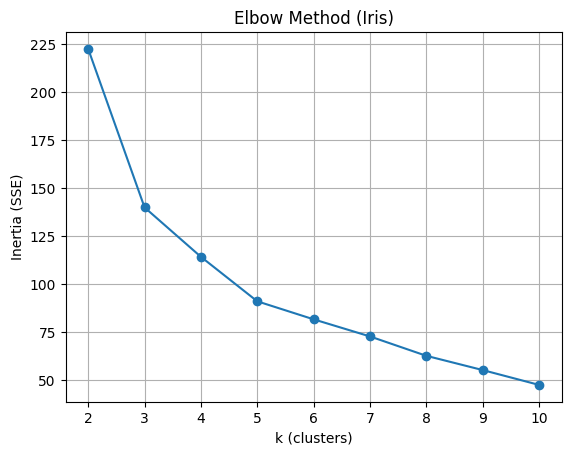

Таңдау қағидасы: графиктегі 'иілу' (elbow) аймағы — жақсы k кандидаты.


In [16]:
inertias = []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.xticks(list(ks))
plt.xlabel("k (clusters)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method (Iris)")
plt.grid(True)
plt.show()

print("Таңдау қағидасы: графиктегі 'иілу' (elbow) аймағы — жақсы k кандидаты.")


### 🔹 Тапсырма 15 (Advanced): KMeans vs DBSCAN vs Hierarchical, Silhouette Score fileciteturn1file2L103-L111

**Шулы дерекке кім жақсы?**  
- **DBSCAN**: noise-ті (-1) деп бөлек шығара алады → шу бар жерде жиі артықшылық.


In [17]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

results = []

# KMeans
km = KMeans(n_clusters=3, random_state=42, n_init=10)
lab_km = km.fit_predict(X_scaled)
sil_km = silhouette_score(X_scaled, lab_km)
results.append(("KMeans(k=3)", sil_km, len(set(lab_km)), 0))

# DBSCAN
db = DBSCAN(eps=0.6, min_samples=5)  # параметрлерді қажет болса өзгертіңіз
lab_db = db.fit_predict(X_scaled)
n_noise = int(np.sum(lab_db == -1))
unique = set(lab_db)
n_clusters_db = len(unique) - (1 if -1 in unique else 0)

if n_clusters_db >= 2:
    sil_db = silhouette_score(X_scaled[lab_db != -1], lab_db[lab_db != -1])
else:
    sil_db = np.nan
results.append((f"DBSCAN(eps=0.6)", sil_db, n_clusters_db, n_noise))

# Hierarchical
agg = AgglomerativeClustering(n_clusters=3)
lab_agg = agg.fit_predict(X_scaled)
sil_agg = silhouette_score(X_scaled, lab_agg)
results.append(("Hierarchical(k=3)", sil_agg, len(set(lab_agg)), 0))

pd.DataFrame(results, columns=["Algorithm", "Silhouette", "n_clusters", "n_noise"])


,Algorithm,Silhouette,n_clusters,n_noise
0,KMeans(k=3),0.459948,3,0
1,DBSCAN(eps=0.6),0.641895,2,26
2,Hierarchical(k=3),0.446689,3,0


## ✅ 6-БӨЛІМ. Mini-project (үлгі)

Құжатта “өз датасетіңді таңда” делінген. fileciteturn1file2L116-L149  
Төменде **Breast Cancer** (sklearn) арқылы үлгі көрсетемін. Сіз Kaggle/CSV берсеңіз, тек `load_data()` бөлігін ауыстырасыз.


In [18]:
# 1) Дерек жүктеу (үлгі ретінде)
def load_data():
    data = load_breast_cancer()
    X = data.data
    y = data.target  # 0/1
    feature_names = data.feature_names
    target_names = data.target_names
    return X, y, feature_names, target_names

Xb, yb, featb, targetb = load_data()
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=42, stratify=yb
)

print("X:", Xb.shape, "| classes:", targetb)


X: (569, 30) | classes: ['malignant' 'benign']


In [ ]:
# 2) Кемінде 3 модель: KNN, SVM, Decision Tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

models = {
    "KNN (k=7 + scaling)": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))]),
    "SVM (RBF + scaling)": Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))]),
    "Decision Tree (depth=5)": DecisionTreeClassifier(max_depth=5, random_state=42)
}

rows = []
cms = {}

for name, model in models.items():
    model.fit(Xb_train, yb_train)
    pred = model.predict(Xb_test)
    acc = accuracy_score(yb_test, pred)
    cm = confusion_matrix(yb_test, pred)
    rows.append((name, acc))
    cms[name] = cm

pd.DataFrame(rows, columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)


In [20]:
# 3) Confusion Matrix көрсету
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

models = {
    "KNN (k=7 + scaling)": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))]),
    "SVM (RBF + scaling)": Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", C=1, gamma="scale", random_state=42))]),
    "Decision Tree (depth=5)": DecisionTreeClassifier(max_depth=5, random_state=42)
}

rows = []
cms = {}

for name, model in models.items():
    model.fit(Xb_train, yb_train)
    pred = model.predict(Xb_test)
    acc = accuracy_score(yb_test, pred)
    cm = confusion_matrix(yb_test, pred)
    rows.append((name, acc))
    cms[name] = cm

best_name = max(models.keys(), key=lambda n: accuracy_score(yb_test, models[n].predict(Xb_test)))
print("Best model:", best_name)
print("Confusion Matrix:\n", cms[best_name])
print("\nClassification report:\n", classification_report(yb_test, models[best_name].predict(Xb_test)))

Best model: SVM (RBF + scaling)
Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Қорғауға дайын аргументтер (қысқа)

- **Неге осы модель?**  
  - Test Accuracy жоғары, Confusion Matrix бойынша қателер аз, және scaling/гиперпараметрлермен жақсы тұрақтылық көрсетеді.  

- **Неге басқалары емес?**  
  - KNN: өлшем көп болса, қашықтық “мәні” әлсірейді; k таңдауға сезімтал.  
  - Decision Tree: overfitting-ке бейім; depth өссе train↑, test↓ болуы мүмкін.  
  - SVM: жақсы, бірақ C/gamma таңдау қажет; GridSearch көмектеседі.


## Тапсыру үшін чек-лист

- Барлық бөлімдер орындалды (KNN, SVM, NB, DT, Clustering, Mini-project). fileciteturn1file2L75-L149  
- Графиктер бар: KNN (k vs acc), Elbow, PCA scatter.  
- Метрикалар бар: accuracy, precision/recall, confusion matrix, silhouette.

Егер мұны **Colab**-та ашсаңыз:  
1) File → Upload notebook  
2) Runtime → Run all
